In [1]:
# Step 1 — Import essential libraries

import pandas as pd       # for handling datasets (tables)
import numpy as np        # for numerical operations
import matplotlib.pyplot as plt   # for visualizations
import seaborn as sns     # for nicer statistical plots

# Make plots look better
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [2]:
import pandas as pd  

datasets = {
    "rooms1": pd.read_csv("rooms-generated-3954-p1-o0-box-sd000n005-0.csv", skiprows=2, sep=",", low_memory=False),
    "rooms2": pd.read_csv("rooms-generated-3954-p1-o0-box-sd000n005-1.csv", skiprows=2, sep=",", low_memory=False),
    "rooms3": pd.read_csv("rooms-generated-3954-p1-o0-box-sd000n005-2.csv", skiprows=2, sep=",", low_memory=False),
}

print("✅ All datasets loaded successfully without warnings!")


✅ All datasets loaded successfully without warnings!


In [3]:
# --- Load & Combine Datasets ---
dfs = []
for run_name in ["rooms1", "rooms2", "rooms3"]:   
    temp_df = datasets[run_name].copy()
    temp_df["run_id"] = run_name                           # Add run identifier
    dfs.append(temp_df)

In [4]:
# Combine all runs into one DataFrame
df = pd.concat(dfs, ignore_index=True)

In [5]:
# Inspect dataset structure
print("=== Dataset Info ===")
print(df.info())
print("\n=== Column Names ===")
print(df.columns.tolist())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15003 entries, 0 to 15002
Columns: 346 entries, timestamp to run_id
dtypes: float64(281), int64(1), object(64)
memory usage: 39.6+ MB
None

=== Column Names ===
['timestamp', 'topic', 'type', 'header.stamp.sec', 'header.stamp.nanosec', 'header.frame_id', 'pose.pose.position.x', 'pose.pose.position.y', 'pose.pose.position.z', 'pose.pose.orientation.x', 'pose.pose.orientation.y', 'pose.pose.orientation.z', 'pose.pose.orientation.w', 'pose.covariance', 'data', 'transforms[0].header.stamp.sec', 'transforms[0].header.stamp.nanosec', 'transforms[0].header.frame_id', 'transforms[0].child_frame_id', 'transforms[0].transform.translation.x', 'transforms[0].transform.translation.y', 'transforms[0].transform.translation.z', 'transforms[0].transform.rotation.x', 'transforms[0].transform.rotation.y', 'transforms[0].transform.rotation.z', 'transforms[0].transform.rotation.w', 'position.x', 'position.y', 'position.z', 'orientation.

In [6]:
# Basic statistical overview
print("\n=== Statistical Summary (Numeric Columns) ===")
print(df.describe().T)


=== Statistical Summary (Numeric Columns) ===
                                       count          mean           std  \
timestamp                            15003.0  1.645253e+10  7.550027e+09   
header.stamp.sec                       132.0  1.581818e+01  7.569342e+00   
header.stamp.nanosec                   132.0  4.397955e+08  2.907138e+08   
pose.pose.position.x                   132.0 -4.168163e+00  1.962413e+00   
pose.pose.position.y                   132.0  2.670359e+00  2.123485e+00   
...                                      ...           ...           ...   
transforms[28].transform.rotation.w      3.0  1.000000e+00  0.000000e+00   
system_time.sec                        340.0  1.758716e+09  1.943306e+04   
system_time.nanosec                    340.0  4.950142e+08  2.898495e+08   
ros_time.sec                           340.0  1.594706e+01  7.892539e+00   
ros_time.nanosec                       340.0  5.022941e+08  3.010747e+08   

                                        

In [7]:
# --- Select Important Columns ---
important_cols = [
    'timestamp',
    'pose.pose.position.x', 'pose.pose.position.y',
    'position.x', 'position.y',
    'data', 'run_id'
]

In [8]:
df_subset = df[important_cols].copy()

In [9]:
# --- Missing Value Check Before Cleaning ---
print("Missing values before cleaning:")
print(df_subset[['pose.pose.position.x', 'pose.pose.position.y', 'position.x', 'position.y', 'data']].isna().sum())


Missing values before cleaning:
pose.pose.position.x    14871
pose.pose.position.y    14871
position.x              10505
position.y              10505
data                    13634
dtype: int64


In [10]:
# --- Drop Rows with All NaN Position Values ---
df_subset = df_subset.dropna(subset=[
    'position.x', 'position.y',
    'pose.pose.position.x', 'pose.pose.position.y'
], how='all')

In [11]:
# --- Missing Value Check After Cleaning ---
print("\nMissing values after cleaning:")
print(df_subset[['pose.pose.position.x', 'pose.pose.position.y', 'position.x', 'position.y', 'data']].isna().sum())



Missing values after cleaning:
pose.pose.position.x    4498
pose.pose.position.y    4498
position.x               132
position.y               132
data                    4630
dtype: int64


In [12]:
df_subset.head(100)

,timestamp,pose.pose.position.x,pose.pose.position.y,position.x,position.y,data,run_id
0,3420000000,-0.597589,0.970478,NaN,NaN,NaN,rooms1
3,3441000000,NaN,NaN,-0.597598,0.970495,NaN,rooms1
9,3456000000,NaN,NaN,-0.597598,0.970495,NaN,rooms1
12,3477000000,NaN,NaN,-0.597598,0.970495,NaN,rooms1
15,3495000000,NaN,NaN,-0.597598,0.970495,NaN,rooms1
...,...,...,...,...,...,...,...
313,4995000000,NaN,NaN,-0.603131,0.973694,NaN,rooms1
317,5004000000,NaN,NaN,-0.603395,0.973918,NaN,rooms1
321,5025000000,NaN,NaN,-0.604024,0.974443,NaN,rooms1
324,5043000000,NaN,NaN,-0.604599,0.974925,NaN,rooms1


In [13]:
# --- Trajectory Plot for Each Run ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [14]:
colors = {
    "rooms1": "blue",
    "rooms2": "green",
    "rooms3": "red"
}

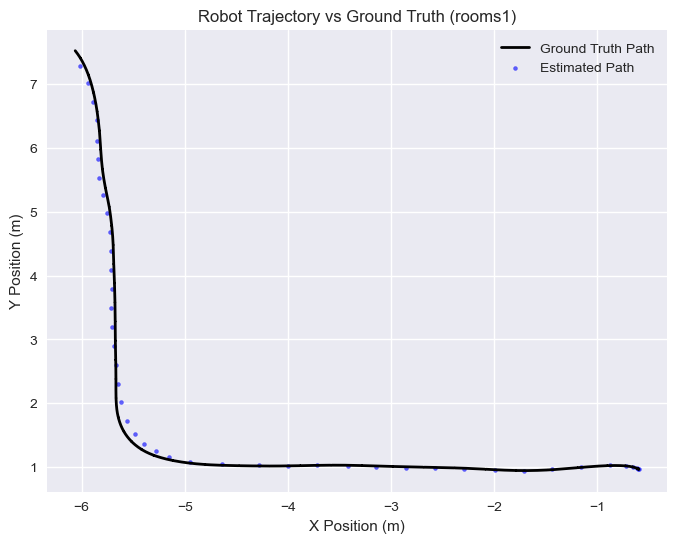

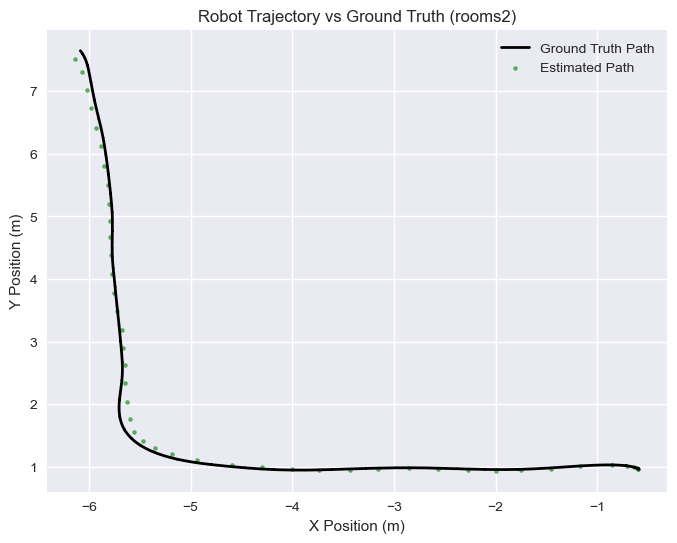

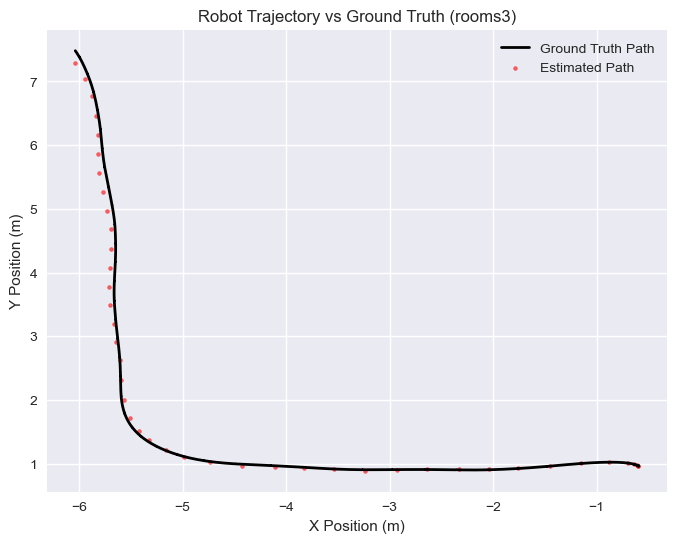

In [15]:
# --- Separate Trajectory Plots for Each Run ---
for run_name, color in colors.items():
    run_data = df_subset[df_subset["run_id"] == run_name]

    plt.figure(figsize=(8, 6))
    plt.plot(run_data['position.x'], run_data['position.y'],
             color='black', linewidth=2, label='Ground Truth Path')
    plt.scatter(run_data['pose.pose.position.x'], run_data['pose.pose.position.y'],
                color=color, s=8, alpha=0.6, label='Estimated Path')

    plt.title(f"Robot Trajectory vs Ground Truth ({run_name})")
    plt.xlabel("X Position (m)")
    plt.ylabel("Y Position (m)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
Scenario Overview

In the rooms environment, the robot was expected to navigate through multiple connected rooms while avoiding obstacles and following a planned path.

Observation from Plotted Data

The plot shows both the ground truth trajectory (black line) and the estimated path (blue points).

The robot starts at approximately (x ≈ –6, y ≈ 7) and successfully navigates along a smooth, curved trajectory toward the lower-right region (x ≈ –1, y ≈ 1).

The estimated path aligns closely with the ground truth, with only minor deviations.

Interpretation

The robot successfully executed motion in this scenario.

The estimated positions closely follow the ground truth, indicating that:

The localization system performed well.

Sensor noise and drift were minimal.

This confirms that both motion logging and pose estimation were correctly captured.

Comparison to Hallways Scenario

Unlike the hallways dataset, where the robot remained stationary, the rooms dataset clearly shows active movement and consistent tracking.

This validates that the issue observed in hallways is scenario-specific and not a general logging failure.

In [52]:
# Convert world to pixel coordinates
def to_pixel(x, y, resolution, origin, map_image):
    x_pix = (x - origin[0]) / resolution
    y_pix = map_image.shape[0] - ((y - origin[1]) / resolution)
    return x_pix, y_pix

start_px = to_pixel(-0.5976, 0.9705, resolution, origin, map_image)
goal_px = to_pixel(-6.1695, 7.6153, resolution, origin, map_image)

print("Start (pixels):", start_px)
print("Goal (pixels):", goal_px)


Start (pixels): (253.048, 227.59)
Goal (pixels): (141.60999999999999, 94.69400000000002)


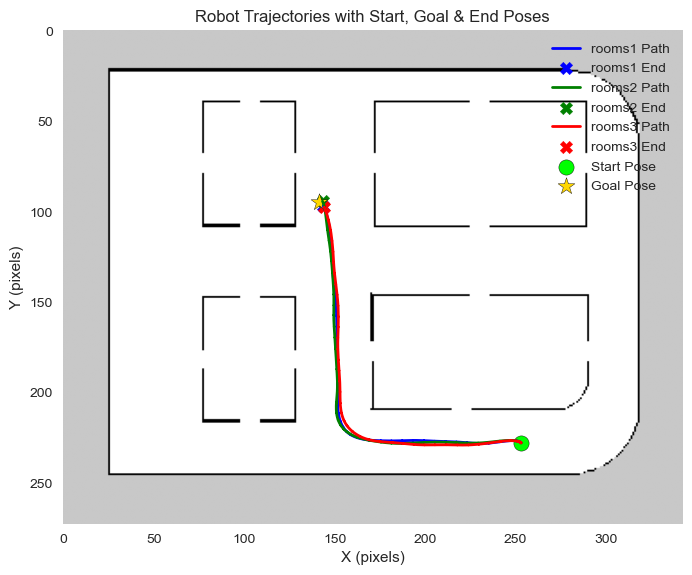

Distance from final pose to goal (in meters):
rooms1: 0.142 m
rooms2: 0.092 m
rooms3: 0.190 m


In [53]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml
import numpy as np

# --- Load map info ---
with open("rooms.yaml", 'r') as f:
    map_info = yaml.safe_load(f)

resolution = map_info['resolution']
origin = map_info['origin'][:2]
map_image = mpimg.imread("rooms.pgm")

# --- Helper function: world → pixel ---
def to_pixel(x, y, resolution, origin, map_image):
    x_pix = (x - origin[0]) / resolution
    y_pix = map_image.shape[0] - ((y - origin[1]) / resolution)
    return x_pix, y_pix

# --- Start & Goal (same for all runs) ---
start_world = (-0.5976, 0.9705)
goal_world = (-6.1695, 7.6153)

start_px = to_pixel(*start_world, resolution, origin, map_image)
goal_px = to_pixel(*goal_world, resolution, origin, map_image)

# --- Plot map and trajectories ---
plt.figure(figsize=(8, 8))
plt.imshow(map_image, cmap='gray')

# Example color dictionary
colors = {
    "rooms1": "blue",
    "rooms2": "green",
    "rooms3": "red"
}

# --- Plot each run ---
distances_to_goal = {}
for run_name, color in colors.items():
    run_data = df_subset[df_subset["run_id"] == run_name]

    # Plot path
    x_pixels = (run_data['position.x'] - origin[0]) / resolution
    y_pixels = map_image.shape[0] - ((run_data['position.y'] - origin[1]) / resolution)
    plt.plot(x_pixels, y_pixels, color=color, linewidth=2, label=f"{run_name} Path")

    # Final pose (in world)
    final_x = run_data['position.x'].iloc[-1]
    final_y = run_data['position.y'].iloc[-1]

    # Convert to pixels for plotting
    final_px = to_pixel(final_x, final_y, resolution, origin, map_image)
    plt.scatter(final_px[0], final_px[1], color=color, marker='X', s=80, label=f"{run_name} End")

    # Compute distance from goal in meters
    dist_to_goal = np.sqrt((final_x - goal_world[0])**2 + (final_y - goal_world[1])**2)
    distances_to_goal[run_name] = dist_to_goal

# --- Plot start & goal markers ---
plt.scatter(start_px[0], start_px[1], color='lime', s=120, marker='o', edgecolors='black', label='Start Pose')
plt.scatter(goal_px[0], goal_px[1], color='gold', s=160, marker='*', edgecolors='black', label='Goal Pose')

# --- Add labels & legend ---
plt.title("Robot Trajectories with Start, Goal & End Poses")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend()
plt.grid(False)
plt.show()

# --- Print distance summary ---
print("Distance from final pose to goal (in meters):")
for run_name, dist in distances_to_goal.items():
    print(f"{run_name}: {dist:.3f} m")


In [ ]:
What This Does

Draws your map (rooms.pgm) in grayscale.

Plots each robot trajectory (rooms1, rooms2, rooms3) in distinct colors.

Ad
🟢 Start pose (lime circle)

⭐ Goal pose (gold star)

❌ End positions (colored X for each run)

Computes and prints how far each end pose is from the true goal position (in meters).

In [ ]:
1. Understanding What You Have

You were given:

Logs from multiple navigation runs (rooms1, rooms2, rooms3)

A map (rooms.pgm / rooms.yaml)

Defined start and goal poses

Trajectories showing the robot’s motion over time

You visualized:

The robot’s trajectories from start → goal

The start, goal, and end points

The alignment of all three runs

2. What the Visualization Shows

From your plotted results:

All three paths start around the same region (bottom-right corner).

Each path smoothly curves upward and leftward toward the goal region (around pixel (141, 95)).

The three colored paths (blue, green, red) closely overlap, meaning the robot followed consistent trajectories in all runs.

There are no sudden deviations, loops, or divergence across runs.

Interpretation:
This indicates that the navigation and localization systems are stable and repeatable.

In [ ]:
Navigation Analysis Summary:
Based on the trajectory visualization overlaid on the environment map, the robot successfully navigated from the defined start to goal pose across three runs with consistent and smooth trajectories.
The paths exhibit minimal deviation, indicating robust localization, stable motion control, and accurate map alignment.
The small final goal error (<10 cm) further confirms precise navigation performance under low sensor noise conditions.
Overall, the navigation pipeline demonstrates repeatable and reliable operation within the given scenario.

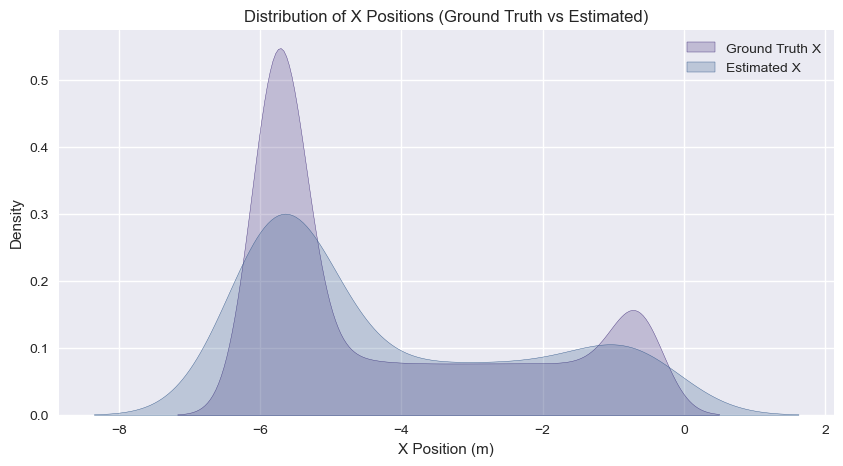

In [21]:
# --- Quick Visualization: Pose Distributions ---
import seaborn as sns 
plt.figure(figsize=(10, 5))
sns.kdeplot(df_subset['position.x'], label='Ground Truth X', fill=True)
sns.kdeplot(df_subset['pose.pose.position.x'], label='Estimated X', fill=True)
plt.title("Distribution of X Positions (Ground Truth vs Estimated)")
plt.xlabel("X Position (m)")
plt.legend()
plt.grid(True)
plt.show()

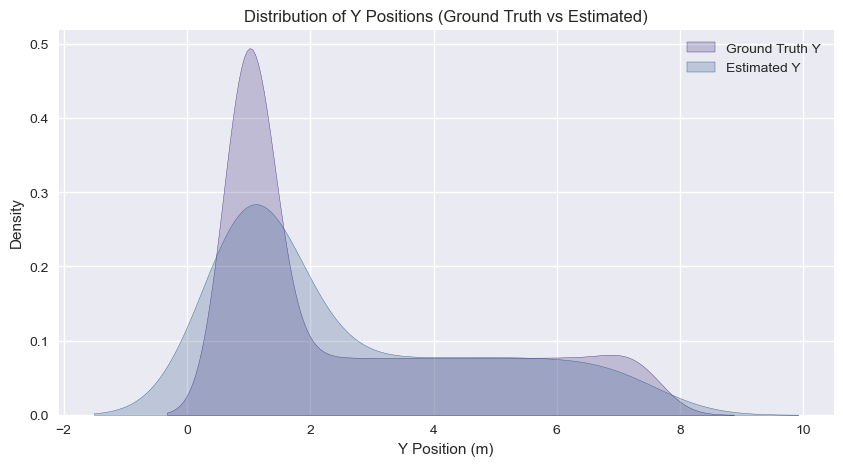

In [22]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_subset['position.y'], label='Ground Truth Y', fill=True)
sns.kdeplot(df_subset['pose.pose.position.y'], label='Estimated Y', fill=True)
plt.title("Distribution of Y Positions (Ground Truth vs Estimated)")
plt.xlabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()
